In [1]:
#################################################################################################
# Given a data file to read, check Tally to see if any downstream packets went missing. This code
# will not check if local packets were lost. This script was written to read 1 data file of
# packets recorded from 1 tile during QC testing for the v3a chip. The data file must have been
# run from a configuration where tally was enabled
#################################################################################################

###############################
# Imports
###############################

import h5py
import matplotlib.pyplot as plt
import yaml
import numpy as np
import argparse
import json
import tqdm

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib import cm
from matplotlib.colors import Normalize
from statistics import mean, mode, stdev
from matplotlib.ticker import PercentFormatter, FixedFormatter, FixedLocator

###############################
# Initialize
###############################

filename = "../data/packet-warm_tally_2025_11_05_12_49_59_PST.h5" # no channels/links disabled. tally on with syncs
filename = "../data/packet-2025_11_19_13_37_10_PST.h5"


# tiles tested in this filename or the subset of tiles on which you wish to check tally 
tiles = [1,2,3,4,5]
chip_serial_number_list = ['', '4k02056', '4k02533', '4k03591', '4k01892', '4k03537']

# if there are misnumbered chips you can see if they came from a chip that has low packet counts using
# the following pairing. List the legitimate chip_id first in this pair 
problem_chip_pair = [[],[161,225],[],[],[],[]]

# the length of time data was recorded. This was set in the program generate_pedestal_config_w_tally.py. 
# The default value is 400000 (or 0.4MHz) 
periodic_trigger_cycles = 400000

# verbose = True will print out a detailed listing of the skipped tally counts
verbose = False

# records tally by chip
tally = [[] for chp in range(256)]

# create various arrays for counting packets, etc
first_tile = True
unique_io_channels = []
bad_chip_count = 0

# background: packet dataset attributes: 
# ('io_group', 'io_channel', 'chip_id', 'packet_type', 'downstream_marker', 'parity', 'valid_parity', 'channel_id', 
# 'timestamp', 'dataword', 'trigger_type', 'local_fifo', 'shared_fifo', 'register_address', 'register_data', 'direction', 
# 'local_fifo_events', 'shared_fifo_events', 'counter', 'fifo_diagnostics_enabled', 'first_packet', 'receipt_timestamp')


In [2]:
def get_io_channels(tile):

    io_ch_per_tile = [
        [],
        [1,2,3,4],
        [5,6,7,8],
        [9,10,11,12],
        [13,14,15,16],
        [17,18,19,20]
                     ]
    
    return io_ch_per_tile[tile]

In [3]:
def get_data(filename):
    
    global unique_chips, tally, receipt_ts, bad_chip_count, missing, pkt_count, first_tile, unique_io_channels
    global problem_chip_pair, tiles, chip_serial_number_list
    
    npkts = 0
    first_problem_chip = True
    
    f = h5py.File(filename, 'r')
    packets = f['packets'][:]

    # determine the time period for this data file
    unixtime = f['packets'][:]['timestamp'][f['packets'][:]['packet_type'] == 4]
    livetime = np.max(unixtime)-np.min(unixtime)

    # mask for sync packets (type 6) and external trigger (type 83)
    sync_mask = (packets['packet_type'] == 6) & (packets['trigger_type'] == 83)
    nsyncs = len(packets[sync_mask]) 

    if first_tile:

        first_tile = False
        
        # plot receipt timestamps before applying rollover
        data_mask     = packets['packet_type']  == 1
        data_pkts_before_rollover   = packets[data_mask]
        receipt_ts_before_rollover  = data_pkts_before_rollover['receipt_timestamp'][:]
    
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.set_title(f'Receipt Timestamp Before Rollover (with {nsyncs} sync pkts)\nBenchtop test of v3a 10x16 tiles')
        ax.plot(receipt_ts_before_rollover)
        ax.set_xlabel("packet")
        ax.set_ylabel("Receipt Timestamp")  
        plt.show
    
#################################################################################################
# create a consistently increasing counting sequence from a saw-toothed series of 
# pacman counts (the "receipt_timestamp")
#################################################################################################

        # rollover will be used to adapt the saw-toothed time series to a consistently-increasing 
        # time series. Begin by creating an array of zeros the length of packets
        rollover = np.zeros((len(packets),), dtype='i8')
            
        # rollover_ticks is an array of the same size as rollover, but holds the value of the 
        # number of ticks in each pacman clock cycle (1E7)
        rollover_ticks = rollover + 1E7
    
        # mask for the sync signal (packet type 6) that's externally generated (trigger_type 83) 
        # to reset the pacman clock and set those elements of rollover to 1E7
        mask = (packets['packet_type'] == 6) & (packets['trigger_type'] == 83)
        rollover[mask] = rollover_ticks[mask]
            
        # Use cumsum to asign the value of 1E7 to each element of rollover, incrementing that 
        # amount by an additional 1E7 at each subsequent sync point
        rollover = np.cumsum(rollover)
            
        # add rollover to each packet's receipt_timestamp to create a consistently-increasing
        # clock sequence for this file
        ts = packets['receipt_timestamp'].astype('i8') + rollover
    
        # sort the counting sequence and the packets by the "rolled over" receipt timestamp
        sorted_idcs = np.argsort(ts)
        sorted_ts = ts[sorted_idcs]
        sorted_pkts = packets[sorted_idcs]
        
        # create arrays of sorted data packets
        data_mask     = sorted_pkts['packet_type']  == 1
        data_pkts     = sorted_pkts[data_mask]
        receipt_ts    = sorted_ts[data_mask]
        npkts         = len(data_pkts)   
        
        print(f"{npkts} data packets were collected over {livetime} seconds (average data rate = {npkts/livetime:.0f} pkts/s)")
    
        fig, ax = plt.subplots(figsize=(5, 3))
        ax.set_title(f'Receipt Timestamp after Rollover (with {nsyncs} sync pkts)\nBenchtop test v3a 10x16 tiles')
        ax.plot(receipt_ts)
        ax.set_xlabel("packet")
        ax.set_ylabel("Receipt Timestamp")  
        plt.show

        # identify io_channels with data packets in this data file
        unique_io_channels = list(dict.fromkeys(data_pkts['io_channel'][:]))

    for tile in tiles:
    
        print(f"\n\n############################ Checking Tile {tile} ###################################")
    
        missing   = np.zeros(256)
        pkt_count = np.zeros(256)
        unique_chips  = []
        bad_chip_count = 0
        
        # get a list of the io_channels that could be enabled for a given tile, and then determine which
        # ones were enabled
        io_channel_ids = get_io_channels(tile)
        enabled_io_channels = list(set(io_channel_ids) & set(unique_io_channels))
        
        # mask for the chosen tile
        tile_mask = (data_pkts['io_channel']== io_channel_ids[0]) | (data_pkts['io_channel']== io_channel_ids[1]) | (data_pkts['io_channel']== io_channel_ids[2]) | (data_pkts['io_channel']== io_channel_ids[3])
        tile_pkts = data_pkts[tile_mask]
        tile_ts   = receipt_ts[tile_mask]
        
        if len(tile_pkts) == 0: 
            print(f'There are no data packets for tile {tile}')        
            return
        
        print(f"{len(tile_pkts)} data packets were collected from tile {tile}")
        
        unique_chips = list(dict.fromkeys(tile_pkts['chip_id'][:]))
        
    #######################################################################################
    # for each chip construct tally and call a function that counts missing packets
    #######################################################################################
        
        for chip in unique_chips:
            
            chip_mask = tile_pkts['chip_id']==chip
            chip_pkts = tile_pkts[chip_mask]
            chip_ts   = tile_ts[chip_mask]
            
            # tally records a sequential count (0-15) assigned to each packet as it enters its home shared FIFO
            # when tally is enabled, its value is stored in a combination of local and shared FIFO registers 
            fifo       = chip_pkts['shared_fifo']
            local_fifo = chip_pkts['local_fifo']
            tally[chip] = 4 * fifo + local_fifo 
            
            count_missing_pkts(chip, tally[chip])
        
        print(f'{bad_chip_count} chips (out of {len(unique_chips)}) skipped a tally in Tile {tile}')
    
        graph_missing(tile)
        
        if len(problem_chip_pair[tile]) > 0:
            combine_chips(problem_chip_pair[tile], tile, tile_pkts, tile_ts)
    
    return 

In [4]:
############################################################################################
# count the missing packets for a given chip using tally
############################################################################################
def count_missing_pkts(chip, chip_tally):
    
    global missing, pkt_count, bad_chip_count
    
    pkt_count[chip] = len(chip_tally)

    for i in range(len(chip_tally)-1):
        if chip_tally[i] == 15:
            if chip_tally[i+1] !=0:
                missing[chip] +=1
        elif chip_tally[i+1] != chip_tally[i]+1:
            missing[chip] +=1
            if verbose: 
                print(f'missing pkt {i} for chip {chip}: skipped tally {chip_tally[i]} to {chip_tally[i+1]}')

    if missing[chip] > 0:
        bad_chip_count +=1
            
    return

In [5]:
def graph_missing(tile):

    global tally, missing, pkt_count, unique_chips
    missing_percent = []

    for chp in unique_chips:

        missing_percent.append( missing[chp] / pkt_count[chp] )

        if missing_percent[-1] > 0:
            
            print(f'\n{100*missing_percent[-1]:.1f}% of packets in Chip {chp} skipped at least 1 Tally: Sample tally[0:20] =\n{tally[chp][0:20]}')

            fig, ax = plt.subplots(figsize=(16, 3))
            ax.set_title(f'Chip {chp} Tally\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
            ax.plot(tally[chp], marker='o')
            ax.set_xlabel("Packet Count Sorted by Receipt Timestamp")
            ax.set_ylabel("Tally") 
            plt.show

            fig, ax = plt.subplots(figsize=(10, 3))
            ax.set_title(f'Chip {chp} Tally[0:200]\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
            ax.plot(tally[chp][0:200], marker='o')
            ax.set_xlabel("Packet Count Sorted by Receipt Timestamp")
            ax.set_ylabel("Tally")
            plt.show
    
    if missing_percent[-1] > 0:
        
        ymin = max(0, min(missing_percent) - 0.005)
        ymax = max(missing_percent) + 0.005
        
        fig, ax = plt.subplots(figsize=(5, 3))
        # Set fixed tick positions and labels
        positions = [0, .1, .25, .5, .75, 1]
        labels = ['0%', '10%', '25%', '50%', '75%', '100%'] 
        
        ax.set_title(f'% Packets that skipped at least 1 Tally by Chip\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
        ax.bar(unique_chips, missing_percent)
        ax.set_xlabel("Chip")
        ax.set_ylabel("Missing Percent")
        ax.set_ylim( min(0,ymax) )
        ax.yaxis.set_major_locator(FixedLocator(positions))
        ax.yaxis.set_major_formatter(FixedFormatter(labels))
        plt.show
    
    return

In [6]:
def combine_chips(chip_pair, tile, tile_pkts, tile_ts):

    combined_tally, combined_ts = [], []
    sorted_missing = 0

    # combine packets and timestamps from the 2 identified chips
    for chip in chip_pair:
    
        chip_mask = tile_pkts['chip_id'] == chip
        chip_pkts = tile_pkts[chip_mask]
        chip_ts   = tile_ts[chip_mask]
        
        # tally records a sequential count (0-15) assigned to each packet as it enters its home shared FIFO
        # when tally is enabled, its value is stored in a combination of local and shared FIFO registers 
        fifo       = chip_pkts['shared_fifo']
        local_fifo = chip_pkts['local_fifo']
        tally = 4 * fifo + local_fifo 

        combined_tally.extend(tally)
        combined_ts.extend(chip_ts)
        
    # sort timestamps and tally by timestamps in order to check the combined tally
    sorted_pairs = sorted(zip(combined_ts, combined_tally))
    sorted_ts, sorted_tally = zip(*sorted_pairs)    

    # check the combined tally
    for i in range(len(sorted_tally)-2):
        if sorted_tally[i] == 15:
            if sorted_tally[i+1] !=0:
                sorted_missing +=1
        elif sorted_tally[i+1] != sorted_tally[i]+1:
            sorted_missing +=1
            if verbose: 
                try:
                    print(f'missing pkt for chip {chip}: skipped tally {tally[chip][i]} to {tally[chip][i+1]}')
                except:
                    print(f'problem with accessing tally for pkt {i+1} in tally in range {len(tally)}')
    
    print(f'\nA test was performed combining packets from {chip_pair[0]} and {chip_pair[1]} where the resulting # of missed tallies = {sorted_missing}')   
    
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.set_title(f'Tally [0:200] from Combining Chips {chip_pair[0]} and {chip_pair[1]}\nBenchtop test of v3a tile #{tile} ({chip_serial_number_list[tile]})')
    ax.plot(sorted_tally[0:200], marker='o')
    ax.set_xlabel("Packet Count Sorted by Receipt Timestamp")
    ax.set_ylabel("Tally")
    plt.show    

    return


7346226 data packets were collected over 115 seconds (average data rate = 63880 pkts/s)


############################ Checking Tile 1 ###################################
1836286 data packets were collected from tile 1
2 chips (out of 161) skipped a tally in Tile 1

13.3% of packets in Chip 225 skipped at least 1 Tally: Sample tally[0:20] =
[ 0  1 12 13 14 15  0  1  2  3  4  5  6  7  8  9 10 11 12 13]

14.4% of packets in Chip 161 skipped at least 1 Tally: Sample tally[0:20] =
[ 2  3  4  5  6  7  8  9 10 11 15  0  1 12 13 14 15  0  1  2]

A test was performed combining packets from 161 and 225 where the resulting # of missed tallies = 0


############################ Checking Tile 2 ###################################
1836649 data packets were collected from tile 2
0 chips (out of 160) skipped a tally in Tile 2


############################ Checking Tile 3 ###################################
1836646 data packets were collected from tile 3
4 chips (out of 160) skipped a tally in Tile 3

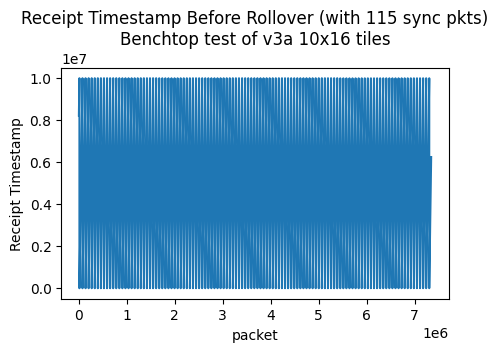

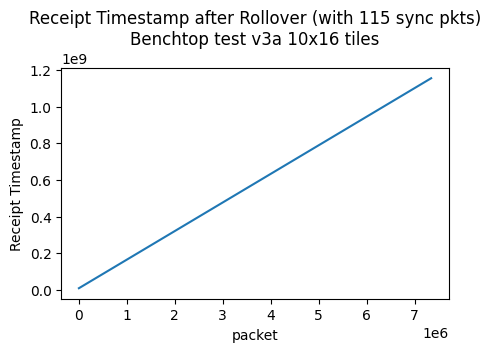

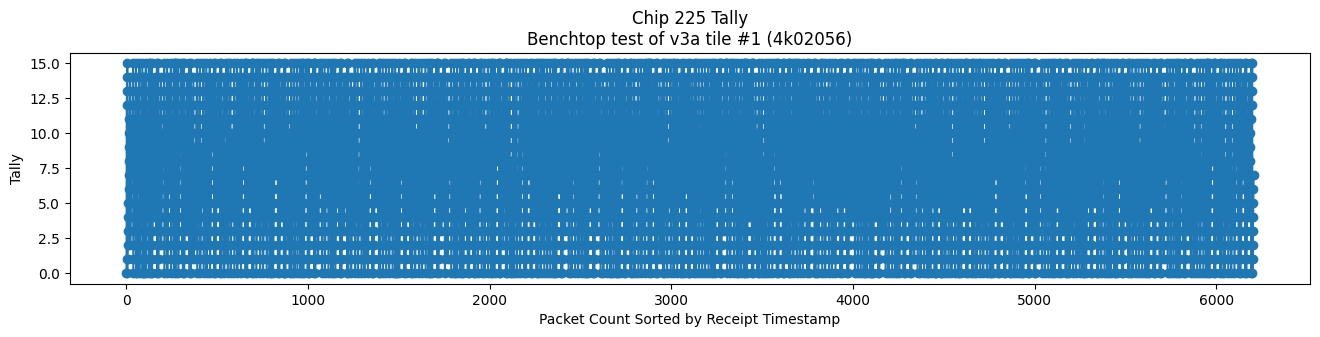

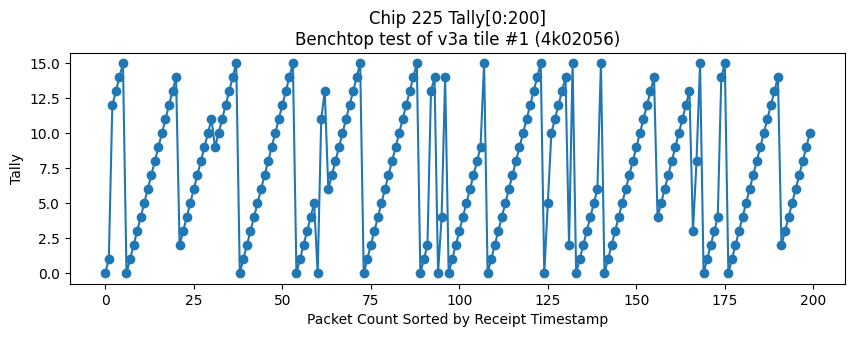

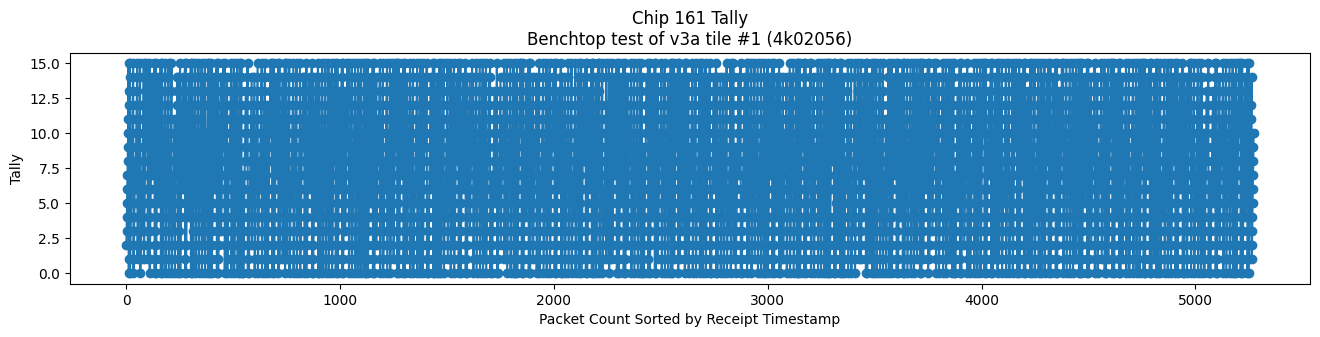

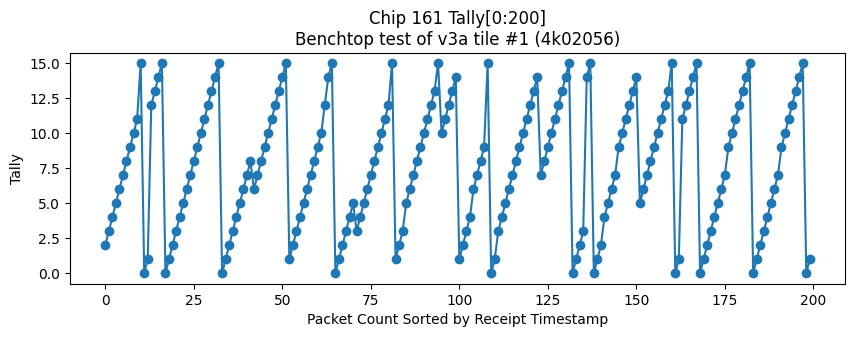

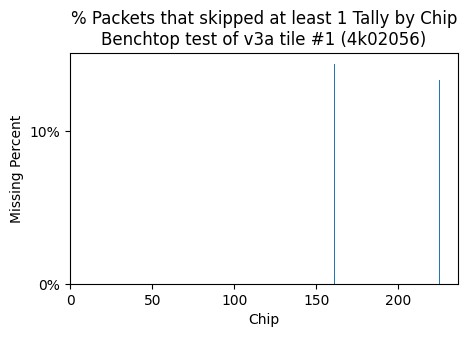

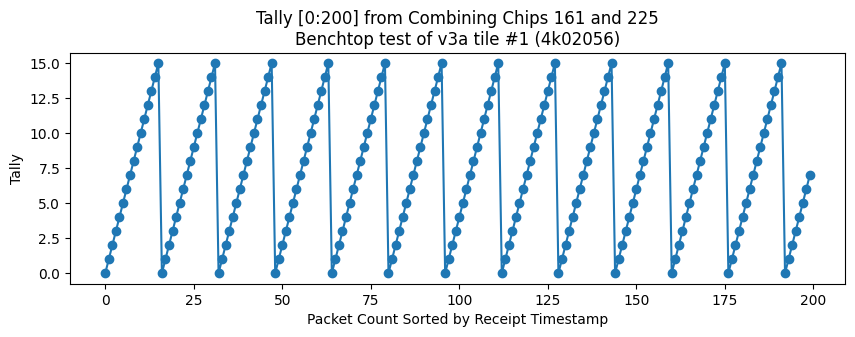

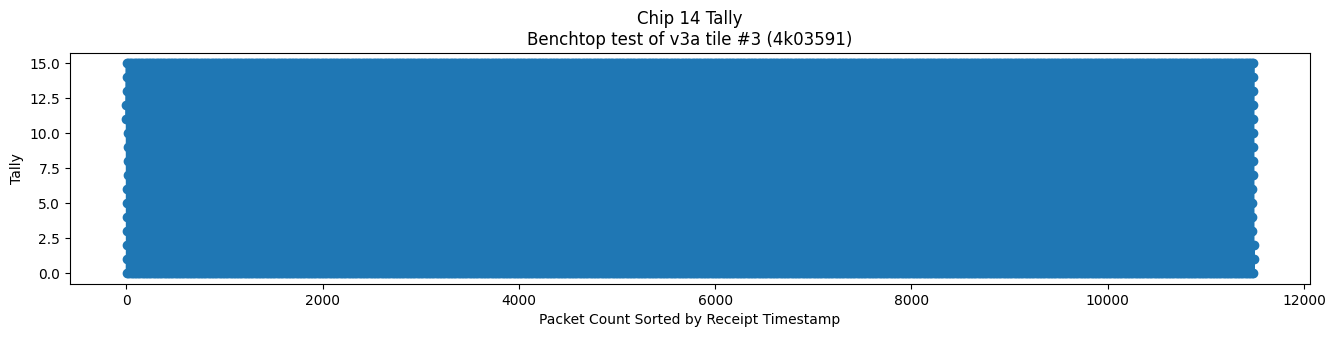

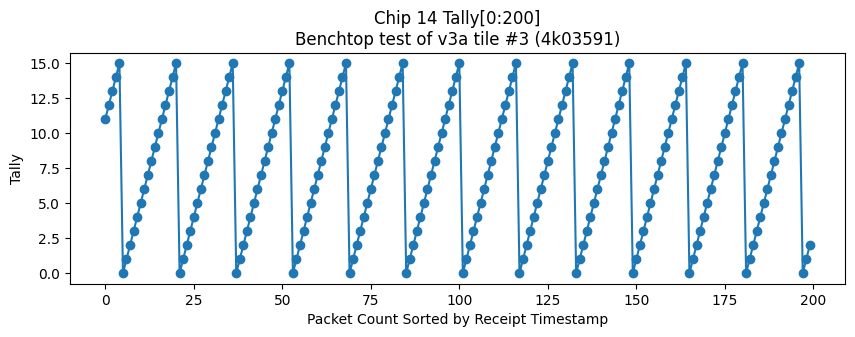

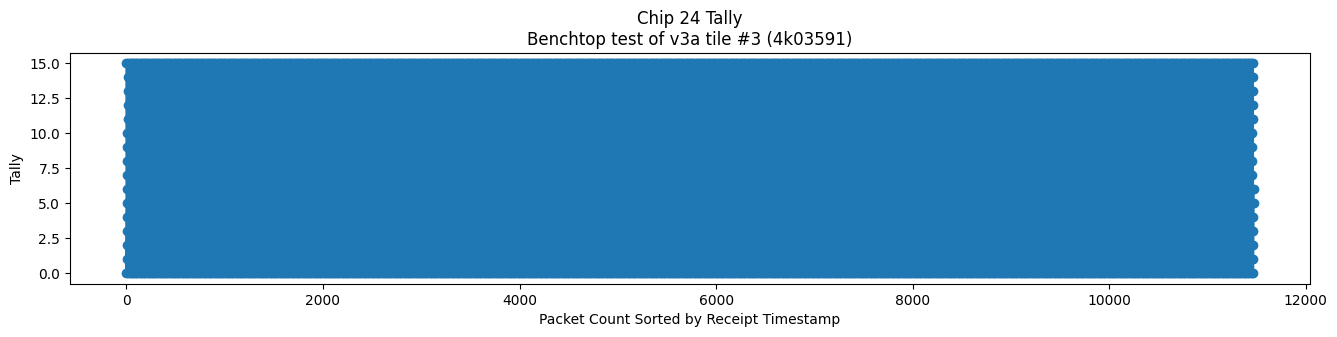

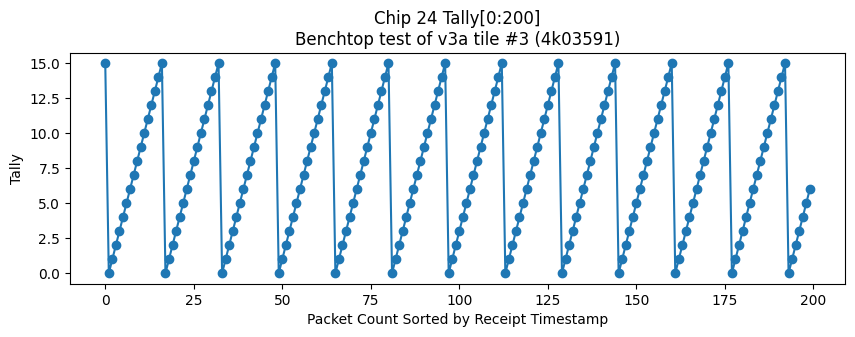

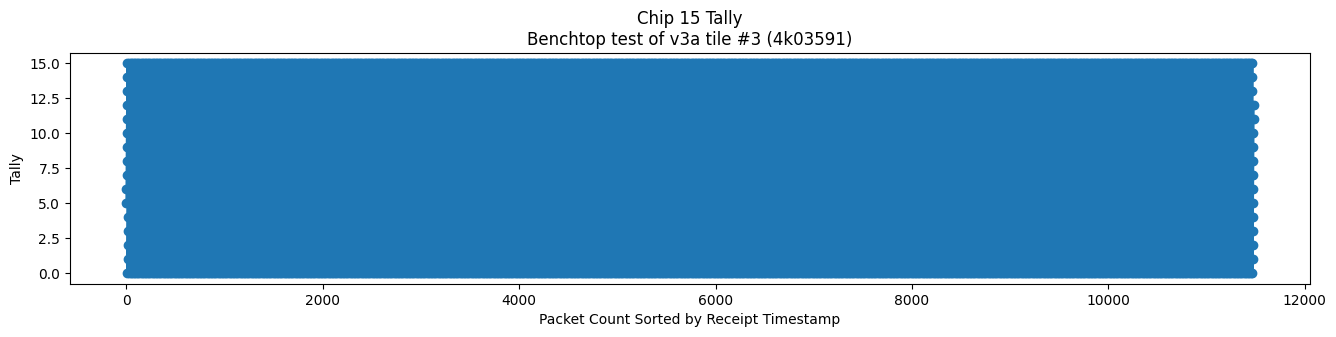

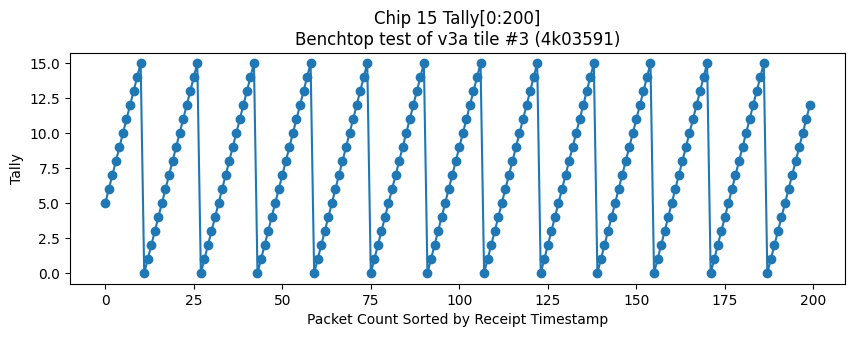

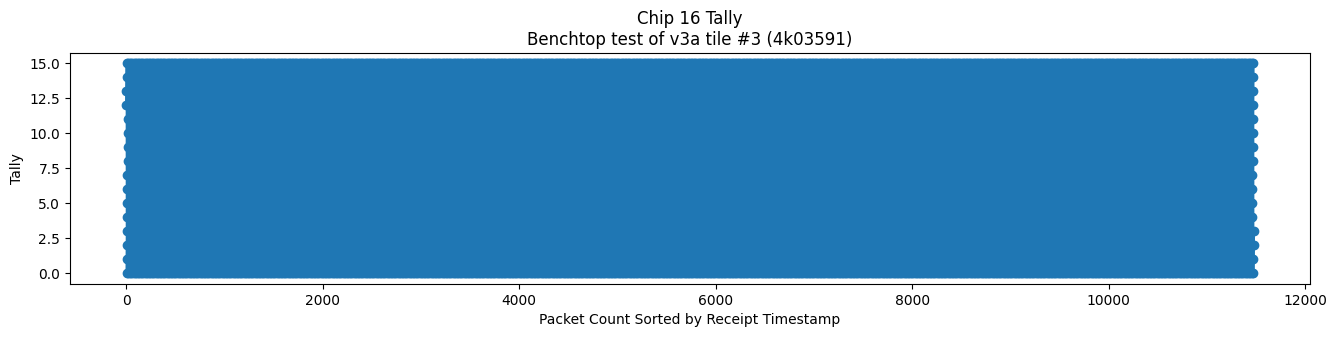

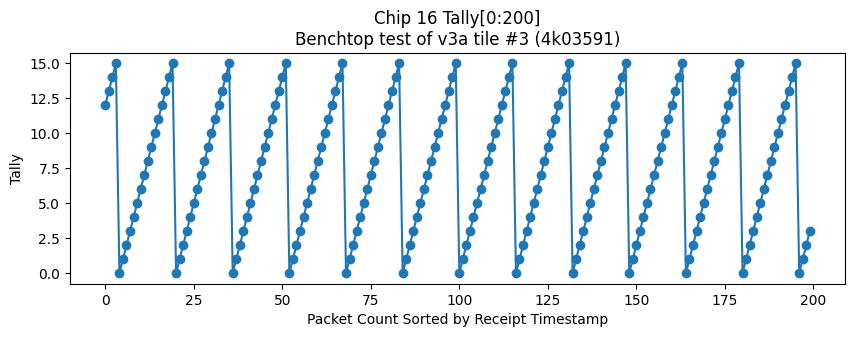

In [7]:
####################
# main
####################

get_data(filename)
